---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 5. Біполярний транзистор: будова, принцип дії, режими</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Будова біполярного транзистора, структури n-p-n і p-n-p, умовні позначення</li>
  <li>Режими роботи: активний, насичення, відсічка, інверсний</li>
  <li>Фізика активного режиму: інжекція, перенесення через базу, екстракція</li>
  <li>Коефіцієнти передачі струму α і β, їх зв'язок з параметрами структури</li>
  <li>Модель Еберса–Молла</li>
  <li>Схеми ввімкнення: зі спільною базою, спільним емітером, спільним колектором</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 5 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Будова біполярного транзистора](#bjt-structure)
* [Режими роботи](#bjt-modes)
* [Принцип дії в активному режимі](#bjt-active)
    * [Складові струмів і коефіцієнти передачі](#bjt-currents)
    * [🔬 Інтерактивно: від чого залежить β](#beta-interactive)
* [Модель Еберса–Молла](#ebers-moll)
    * [⚙️ PySpice: режими роботи транзистора 2N3904](#spice-modes)
* [Схеми ввімкнення біполярного транзистора](#bjt-configs)
    * [⚙️ PySpice: коефіцієнти передачі струму в схемах СБ, СЕ, СК](#spice-configs)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

---

# Будова біполярного транзистора <a class="anchor" id="bjt-structure"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Описувати будову біполярного транзистора, розрізняти структури n-p-n і p-n-p та їх умовні позначення
> - Визначати режим роботи транзистора за полярністю напруг на переходах
> - Пояснювати фізичні процеси в активному режимі: інжекцію, перенесення через базу, екстракцію
> - Обчислювати коефіцієнти α і β та пояснювати, як вони залежать від будови транзистора
> - Записувати рівняння Еберса–Молла і будувати еквівалентну схему
> - Порівнювати схеми ввімкнення СБ, СЕ, СК за підсиленням і опорами

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Біполярний транзистор (БТ)** | Прилад з двома взаємодіючими p-n переходами; струм переносять носії обох знаків |
| **Емітер (Е)** | Сильно легована область, що інжектує носії в базу |
| **База (Б)** | Тонка ($W \ll L$) і слабше легована середня область |
| **Колектор (К)** | Область, що екстрагує носії, які пройшли базу; легована найслабше |
| **Емітерний перехід (ЕП) / колекторний перехід (КП)** | Переходи емітер–база і база–колектор |
| **$\alpha = I_к/I_е$, $\beta = I_к/I_б$** | Коефіцієнти передачі струму емітера і бази, $\beta = \alpha/(1-\alpha)$ |

**Біполярний транзистор** — напівпровідниковий прилад з трьома областями почергової провідності, що утворюють два p-n переходи: **n-p-n** або **p-n-p**. Середня область — **база** — дуже тонка (0,1–1 мкм у сучасних приладах; значно менше за дифузійну довжину неосновних носіїв). Тому переходи **взаємодіють**: носії, інжектовані одним переходом, доходять до іншого. Саме це відрізняє транзистор від двох зустрічно з'єднаних діодів.

Структура несиметрична: **емітер** легують найсильніше ($10^{19}$–$10^{21}$ см⁻³), базу — слабше ($10^{16}$–$10^{18}$), **колектор** — найслабше ($10^{15}$–$10^{16}$), щоб колекторний перехід витримував велику напругу. Площа колекторного переходу більша за емітерний, щоб збирати всі носії.

Сучасні транзистори виготовляють за **планарно-епітаксійною** технологією: на підкладці вирощують епітаксійний шар колектора, у нього дифузією (імплантацією) послідовно вводять базу й емітер. Усі виводи розташовані на верхній поверхні, а сильно легований **прихований шар** $n^+$ зменшує опір колектора.

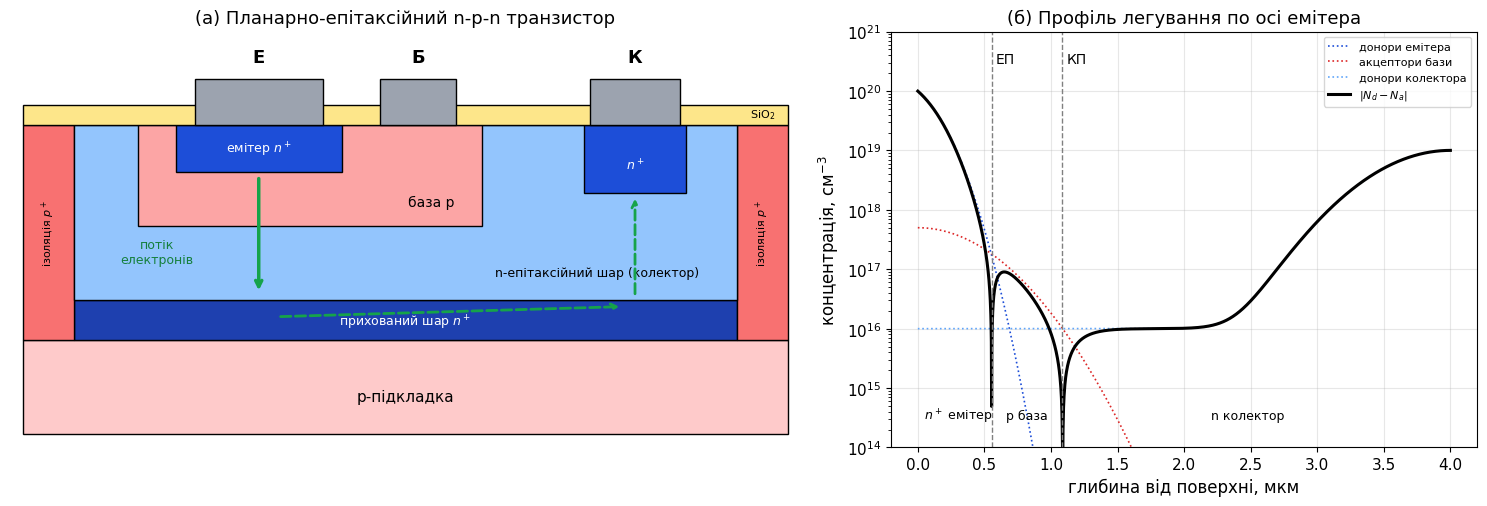

Глибини переходів: емітерного 0.55 мкм, колекторного 1.09 мкм; металургійна ширина бази 0.53 мкм


In [2]:
# (а) Переріз планарно-епітаксійного n-p-n транзистора (не в масштабі); (б) профіль легування вздовж осі емітера
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
ax = axes[0]
R = lambda x, y, w, h, fc, **kw: ax.add_patch(patches.Rectangle((x, y), w, h, fc=fc, ec='k', lw=1, **kw))
R(0, 0, 12, 1.4, '#fecaca'); ax.text(6, 0.5, 'p-підкладка', ha='center')
R(0.8, 1.4, 10.4, 0.6, '#1e40af'); ax.text(6, 1.62, 'прихований шар $n^+$', ha='center', color='white', fontsize=9)
R(0, 1.4, 0.8, 3.2, '#f87171'); R(11.2, 1.4, 0.8, 3.2, '#f87171')
ax.text(0.4, 3.0, 'ізоляція $p^+$', rotation=90, ha='center', va='center', fontsize=8)
ax.text(11.6, 3.0, 'ізоляція $p^+$', rotation=90, ha='center', va='center', fontsize=8)
R(0.8, 2.0, 10.4, 2.6, '#93c5fd'); ax.text(9.0, 2.35, 'n-епітаксійний шар (колектор)', ha='center', fontsize=9)
R(1.8, 3.1, 5.4, 1.5, '#fca5a5'); ax.text(6.4, 3.4, 'база p', ha='center', fontsize=10)
R(2.4, 3.9, 2.6, 0.7, '#1d4ed8'); ax.text(3.7, 4.2, 'емітер $n^+$', ha='center', color='white', fontsize=9)
R(8.8, 3.6, 1.6, 1.0, '#1d4ed8'); ax.text(9.6, 3.95, '$n^+$', ha='center', color='white', fontsize=9)
R(0, 4.6, 12, 0.3, '#fde68a'); ax.text(11.4, 4.72, 'SiO$_2$', fontsize=8)
for x0, w, lab in [(2.7, 2.0, 'Е'), (5.6, 1.2, 'Б'), (8.9, 1.4, 'К')]:
    R(x0, 4.6, w, 0.7, '#9ca3af'); ax.text(x0 + w/2, 5.55, lab, ha='center', fontsize=13, fontweight='bold')
ax.annotate('', xy=(3.7, 2.1), xytext=(3.7, 3.85), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2.5))
ax.annotate('', xy=(9.4, 1.9), xytext=(4.0, 1.75), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2, ls='--'))
ax.annotate('', xy=(9.6, 3.55), xytext=(9.6, 2.05), arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2, ls='--'))
ax.text(2.1, 2.55, 'потік\nелектронів', color='#15803d', fontsize=9, ha='center')
ax.set_xlim(-0.2, 12.2); ax.set_ylim(-0.2, 6.0); ax.axis('off'); ax.set_title('(а) Планарно-епітаксійний n-p-n транзистор')
# (б) профіль легування: емітер (erfc), база (гаус), колектор (епі 1e16) + прихований шар
from scipy.special import erfc
x = np.linspace(0, 4.0, 2000)                           # мкм
NE = 1e20*erfc(x/0.25)
NB = 5e17*np.exp(-(x/0.55)**2)
NC = 1e16 + 1e19*np.exp(-((x - 4.0)/0.6)**2)
net = NE + NC - NB
ax = axes[1]
ax.semilogy(x, NE, ':', color='#1d4ed8', lw=1.2, label='донори емітера')
ax.semilogy(x, NB, ':', color='#dc2626', lw=1.2, label='акцептори бази')
ax.semilogy(x, NC, ':', color='#60a5fa', lw=1.2, label='донори колектора')
ax.semilogy(x, np.abs(net), 'k', lw=2.2, label='$|N_d - N_a|$')
zc = np.where(np.diff(np.sign(net)))[0]
for z, lab in zip(zc, ['ЕП', 'КП']):
    ax.axvline(x[z], color='gray', ls='--', lw=1); ax.text(x[z] + 0.03, 3e20, lab, fontsize=10)
ax.text(0.05, 3e14, '$n^+$ емітер', fontsize=9); ax.text((x[zc[0]] + x[zc[1]])/2, 3e14, 'p база', ha='center', fontsize=9)
ax.text(2.2, 3e14, 'n колектор', fontsize=9)
ax.set_ylim(1e14, 1e21); ax.set_xlabel('глибина від поверхні, мкм'); ax.set_ylabel('концентрація, см$^{-3}$')
ax.set_title('(б) Профіль легування по осі емітера'); ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()
print(f'Глибини переходів: емітерного {x[zc[0]]:.2f} мкм, колекторного {x[zc[1]]:.2f} мкм; металургійна ширина бази {x[zc[1]]-x[zc[0]]:.2f} мкм')

Умовні графічні позначення (за ДСТУ — з колом, позиційне позначення **VT**). Стрілка на емітері показує напрямок струму емітера (прямий напрямок емітерного переходу): у n-p-n вона спрямована **від бази**, у p-n-p — **до бази**. У n-p-n транзистора струми втікають у базу й колектор і витікають з емітера; у p-n-p усі напрямки струмів і полярності напруг протилежні.

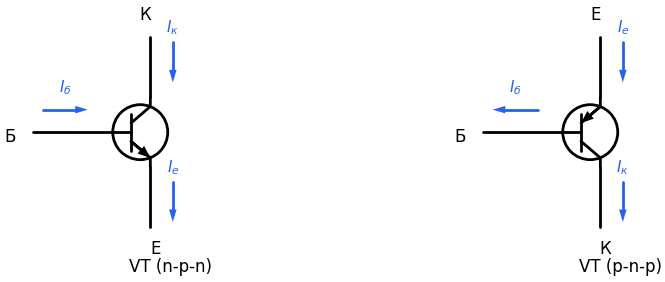

In [3]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2) as d:
        NAMES = {'base': 'Б', 'collector': 'К', 'emitter': 'Е'}
        # для n-p-n струми Iб, Iк втікають, Iе витікає; для p-n-p — навпаки
        for x0, E, name, into in [(0, elm.BjtNpn, 'n-p-n', {'base': True, 'collector': True, 'emitter': False}),
                                  (9, elm.BjtPnp, 'p-n-p', {'base': False, 'collector': False, 'emitter': True})]:
            t = d.add(E(circle=True).at((x0, 0)).theta(0))       # явна орієнтація: база ліворуч
            cx, cy = t.center
            for term in ['base', 'collector', 'emitter']:
                ax_, ay_ = t.absanchors[term]
                if term == 'base':
                    end = (ax_ - 1.6, ay_); d.add(elm.Line().endpoints((ax_, ay_), end))
                    d.add(elm.Label().at((end[0] - 0.35, end[1])).label(NAMES[term]))
                    p0, p1 = (ax_ - 1.4, ay_ + 0.45), (ax_ - 0.5, ay_ + 0.45)
                else:
                    sgn = 1 if ay_ > cy else -1
                    end = (ax_, ay_ + 1.2*sgn); d.add(elm.Line().endpoints((ax_, ay_), end))
                    d.add(elm.Label().at((end[0], end[1] + 0.35*sgn)).label(NAMES[term]))
                    p0, p1 = (ax_ + 0.45, ay_ + 1.1*sgn), (ax_ + 0.45, ay_ + 0.3*sgn)
                if not into[term]: p0, p1 = p1, p0
                d.add(elm.Arrow().endpoints(p0, p1).color('#2563eb').label(f'$I_{{{NAMES[term].lower()}}}$', loc='top' if term == 'base' else 'right', fontsize=11))
            d.add(elm.Label().at((cx + 0.3, cy - 2.6)).label(f'VT ({name})'))

---

# Режими роботи <a class="anchor" id="bjt-modes"></a>

Стан кожного з двох переходів може бути прямим або зворотним, тому транзистор має **чотири режими** (для n-p-n: $U_{БЕ} > 0$ — ЕП прямо, $U_{БК} > 0$ — КП прямо):

| Режим | ЕП | КП | Властивості | Застосування |
|---|---|---|---|---|
| **Активний (нормальний)** | прямий | зворотний | $I_к = \beta I_б$, струм колектора керується струмом бази і майже не залежить від $U_{КЕ}$ | підсилювачі |
| **Насичення** | прямий | прямий | обидва переходи інжектують; $U_{КЕ.нас} \approx 0{,}05$–$0{,}3$ В, $I_к < \beta I_б$ | замкнений ключ |
| **Відсічка** | зворотний | зворотний | лише малі теплові струми | розімкнений ключ |
| **Інверсний** | зворотний | прямий | емітер і колектор міняються ролями, $\beta_I$ ≈ 0,1–5 | рідко (ТТЛ-логіка) |

Для n-p-n транзистора зі спільним емітером зручно пам'ятати: **активний режим** — $U_{БЕ} \approx 0{,}6$–$0{,}75$ В і $U_{КЕ} > U_{БЕ}$; **насичення** — $U_{КЕ} < U_{БЕ}$ (колектор нижче бази); **відсічка** — $U_{БЕ} < 0{,}4$–$0{,}5$ В.

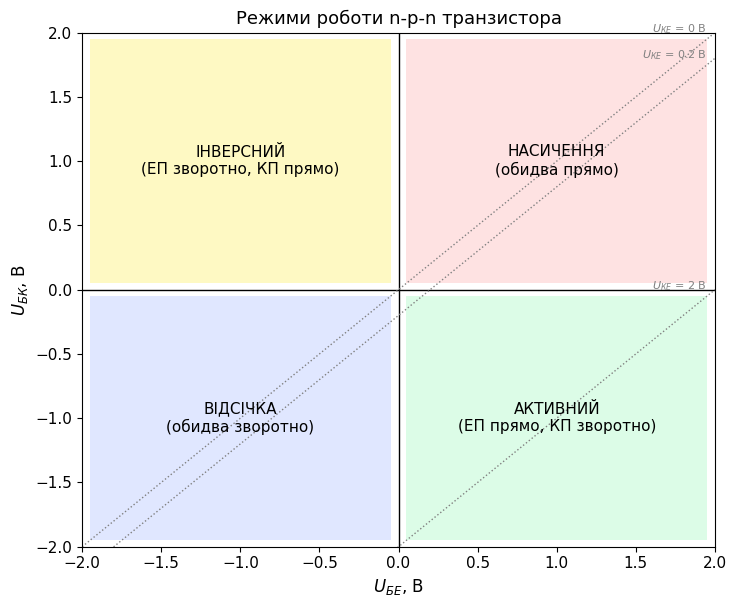

In [4]:
# Карта режимів на площині (U_БЕ, U_БК) для n-p-n
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.axhline(0, color='k', lw=1); ax.axvline(0, color='k', lw=1)
for (x0, y0), name, col in [((0.05, -1.95), 'АКТИВНИЙ\n(ЕП прямо, КП зворотно)', '#dcfce7'), ((0.05, 0.05), 'НАСИЧЕННЯ\n(обидва прямо)', '#fee2e2'),
                             ((-1.95, -1.95), 'ВІДСІЧКА\n(обидва зворотно)', '#e0e7ff'), ((-1.95, 0.05), 'ІНВЕРСНИЙ\n(ЕП зворотно, КП прямо)', '#fef9c3')]:
    ax.add_patch(patches.Rectangle((x0, y0), 1.9, 1.9, fc=col, ec='none'))
    ax.text(x0 + 0.95, y0 + 0.95, name, ha='center', va='center', fontsize=11)
u = np.linspace(-2, 2, 10)
for Uce in [0, 0.2, 2, 5]:
    ax.plot(u, u - Uce, ':', color='gray', lw=1)
    if -2 < 1.95 - Uce < 2: ax.text(1.95, 1.95 - Uce + 0.05, f'$U_{{КЕ}}$ = {Uce} В', ha='right', fontsize=8, color='gray')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_xlabel('$U_{БЕ}$, В'); ax.set_ylabel('$U_{БК}$, В')
ax.set_title('Режими роботи n-p-n транзистора'); ax.grid(False)
plt.tight_layout(); plt.show()

---

# Принцип дії в активному режимі <a class="anchor" id="bjt-active"></a>

Розглянемо n-p-n транзистор в активному режимі:

1. **Інжекція.** Прямо зміщений емітерний перехід знижує бар'єр, і сильно легований емітер інжектує в базу велику кількість електронів (струм $I_{еn}$). Зустрічний потік дірок з бази в емітер ($I_{еp}$) малий, бо база легована набагато слабше.
2. **Перенесення через базу.** Інжектовані електрони — неосновні носії в базі — **дифундують** до колекторного переходу: їх концентрація спадає від $n_p(0) = n_{p0}e^{U_{БЕ}/\varphi_T}$ біля емітера майже до нуля біля колектора. Оскільки товщина бази $W \ll L_n$, рекомбінує лише незначна їх частина.
3. **Екстракція.** Поле зворотно зміщеного колекторного переходу «підхоплює» електрони, що досягли його межі, і перекидає в колектор. Колекторний струм майже дорівнює струму емітера і **не залежить від напруги на колекторі** — колектор поводиться як джерело струму.
4. **Струм бази** складається з дірок, що інжектуються в емітер, і дірок, які поповнюють рекомбінацію в базі (плюс малий зворотний струм колектора $I_{КБО}$ з протилежним знаком).

Головна ідея підсилення: малий струм бази $I_б$ керує в $\beta$ разів більшим струмом колектора, а колекторне коло може мати велику напругу й опір навантаження — отже, **підсилюються і струм, і напруга, і потужність**.

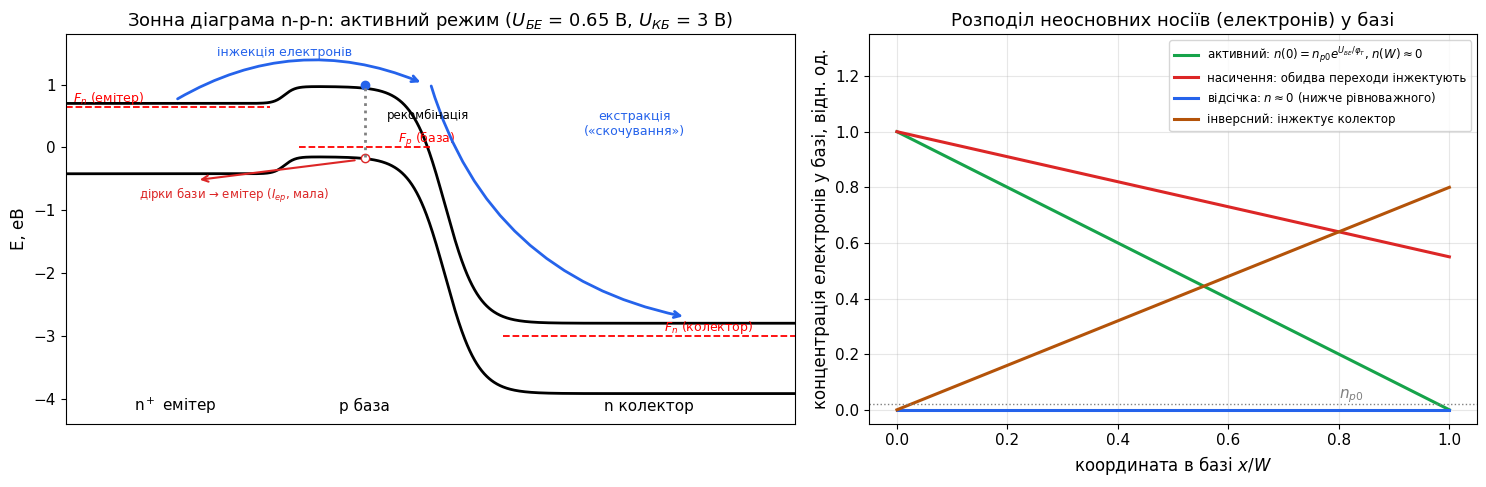

In [5]:
# Зонна діаграма n-p-n в активному режимі (U_БЕ = 0,65 В, U_КБ = 3 В) та розподіл неосновних носіїв у базі в чотирьох режимах
Eg = 1.12
def step(x, x0, w): return 0.5*(1 + np.tanh((x - x0)/w))
x = np.linspace(0, 10, 1200)
U_BE, U_CB = 0.65, 3.0
EcE, EcB, EcC = U_BE + 0.05, 0.97, -U_CB + 0.2         # відлік — квазірівень дірок у базі F_p = 0
Ec = EcE + (EcB - EcE)*step(x, 3.0, 0.15) + (EcC - EcB)*step(x, 5.2, 0.45)
Ev = Ec - Eg
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw=dict(width_ratios=[1.2, 1]))
ax = axes[0]
ax.plot(x, Ec, 'k', lw=2); ax.plot(x, Ev, 'k', lw=2)
ax.plot([0, 2.8], [U_BE]*2, 'r--', lw=1.3); ax.text(0.1, U_BE + 0.08, '$F_n$ (емітер)', color='r', fontsize=9)
ax.plot([3.2, 5.0], [0, 0], 'r--', lw=1.3); ax.text(4.55, 0.07, '$F_p$ (база)', color='r', fontsize=9)
ax.plot([6.0, 10], [-U_CB]*2, 'r--', lw=1.3); ax.text(8.2, -U_CB + 0.08, '$F_n$ (колектор)', color='r', fontsize=9)
ax.annotate('', xy=(4.9, EcB + 0.05), xytext=(1.5, EcE + 0.05), arrowprops=dict(arrowstyle='->', color='#2563eb', lw=2,
            connectionstyle='arc3,rad=-0.25'))
ax.annotate('', xy=(8.5, EcC + 0.1), xytext=(5.0, EcB + 0.05), arrowprops=dict(arrowstyle='->', color='#2563eb', lw=2,
            connectionstyle='arc3,rad=0.3'))
ax.text(3.0, 1.45, 'інжекція електронів', color='#2563eb', fontsize=9, ha='center')
ax.text(7.8, 0.2, 'екстракція\n(«скочування»)', color='#2563eb', fontsize=9, ha='center')
ax.annotate('', xy=(1.8, U_BE - Eg - 0.05), xytext=(4.0, EcB - Eg - 0.05), arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.5))
ax.text(1.0, U_BE - Eg - 0.35, 'дірки бази → емітер ($I_{еp}$, мала)', color='#dc2626', fontsize=8.5)
ax.plot(4.1, EcB + 0.02, 'o', color='#2563eb', ms=6); ax.plot(4.1, EcB - Eg - 0.02, 'o', mfc='white', mec='#dc2626', ms=6)
ax.annotate('рекомбінація', xy=(4.1, 0.3), xytext=(4.4, 0.45), fontsize=8.5)
ax.plot([4.1, 4.1], [EcB - Eg, EcB], ':', color='gray')
for xc, lab in [(1.5, 'n$^+$ емітер'), (4.1, 'p база'), (8.0, 'n колектор')]:
    ax.text(xc, -4.2, lab, ha='center', fontsize=11)
ax.set_xlim(0, 10); ax.set_ylim(-4.4, 1.8); ax.set_xticks([]); ax.set_ylabel('E, еВ')
ax.set_title(f'Зонна діаграма n-p-n: активний режим ($U_{{БЕ}}$ = {U_BE} В, $U_{{КБ}}$ = {U_CB:.0f} В)'); ax.grid(False)
ax = axes[1]
xb = np.linspace(0, 1, 100); npk = np.exp(12)                   # n_p0·e^(U/φT) у відносних одиницях
for (n0, nW), lab, col in [((1.0, 0.0), 'активний: $n(0) = n_{p0}e^{U_{БЕ}/\\varphi_T}$, $n(W) \\approx 0$', '#16a34a'),
                           ((1.0, 0.55), 'насичення: обидва переходи інжектують', '#dc2626'),
                           ((0.0, 0.0), 'відсічка: $n \\approx 0$ (нижче рівноважного)', '#2563eb'),
                           ((0.0, 0.8), 'інверсний: інжектує колектор', '#b45309')]:
    ax.plot(xb, n0 + (nW - n0)*xb, color=col, lw=2.2, label=lab)
ax.axhline(0.02, color='gray', ls=':', lw=1); ax.text(0.8, 0.04, '$n_{p0}$', color='gray')
ax.set_xlabel('координата в базі $x/W$'); ax.set_ylabel('концентрація електронів у базі, відн. од.')
ax.set_title('Розподіл неосновних носіїв (електронів) у базі'); ax.legend(fontsize=8.5, loc='upper right')
ax.set_ylim(-0.05, 1.35)
plt.tight_layout(); plt.show()

## Складові струмів і коефіцієнти передачі <a class="anchor" id="bjt-currents"></a>

Струм емітера $I_е = I_{еn} + I_{еp}$; до колектора доходить частка $\varkappa$ інжектованих електронів. Тоді

$$I_к = \alpha I_е + I_{КБО}, \qquad \alpha = \gamma\cdot\varkappa, \qquad I_е = I_к + I_б,$$

де **коефіцієнт інжекції** (ефективність емітера) і **коефіцієнт перенесення** через базу:

$$\gamma = \frac{I_{еn}}{I_{еn} + I_{еp}} \approx \frac{1}{1 + \dfrac{D_pN_BW}{D_nN_EL_p}}, \qquad \varkappa \approx 1 - \frac{W^2}{2L_n^2}.$$

**Коефіцієнт передачі струму бази**

$$\beta = \frac{I_к}{I_б} = \frac{\alpha}{1-\alpha}, \qquad I_к = \beta I_б + (\beta+1)I_{КБО} = \beta I_б + I_{КЕО}.$$

Оскільки $\alpha$ близький до одиниці (0,98–0,998), $\beta$ дуже чутливий до нього: $\alpha = 0{,}99 \Rightarrow \beta = 99$; $\alpha = 0{,}995 \Rightarrow \beta = 199$. Тому **тонка база** (великий $\varkappa$) і **сильно легований емітер** (великий $\gamma$) — умови великого підсилення. Струм $I_{КЕО} = (\beta+1)I_{КБО}$ — зворотний струм колектора при розімкненій базі — в $\beta$ разів більший за $I_{КБО}$, бо зворотний струм колектора, потрапляючи в базу, підсилюється транзистором.

### 🔬 Інтерактивно: від чого залежить β <a class="anchor" id="beta-interactive"></a>

Розрахунок за наведеними формулами для кремнієвого n-p-n транзистора: рухливості — за моделлю Caughey–Thomas; дифузійна довжина дірок в емітері $L_p$ = 1 мкм (сильне легування), час життя електронів у базі задається повзунком. Реальні транзистори мають дещо менший $\beta$ через рекомбінацію в ОПЗ емітерного переходу і звуження забороненої зони сильно легованого емітера.

In [6]:
def mu_CT(N, carrier):
    if carrier == 'n': return 68.5 + (1414 - 68.5)/(1 + (N/9.2e16)**0.711)
    return 44.9 + (470.5 - 44.9)/(1 + (N/2.23e17)**0.719)

def beta_calc(W_um=1.0, lgNB=17.0, lgNE=19.0, tau_ns=100):
    NB, NE = 10**lgNB, 10**lgNE
    Dn = mu_CT(NB, 'n')*phi_T(); Dp = mu_CT(NE, 'p')*phi_T()
    Ln = np.sqrt(Dn*tau_ns*1e-9)*1e4; Lp = 1.0
    gamma = 1/(1 + Dp*NB*W_um/(Dn*NE*Lp))
    kappa = 1 - W_um**2/(2*Ln**2)
    alpha = gamma*kappa; beta = alpha/(1 - alpha)
    Ws = np.linspace(0.1, 5, 200)
    b_W = [(1/(1 + Dp*NB*w/(Dn*NE*Lp)))*(1 - w**2/(2*Ln**2)) for w in Ws]
    b_W = np.array(b_W); b_W = b_W/(1 - b_W)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].bar(['γ (інжекція)', 'ϰ (перенесення)', 'α = γϰ'], [1 - gamma, 1 - kappa, 1 - alpha], color=['#2563eb', '#16a34a', '#7c3aed'])
    axes[0].set_yscale('log'); axes[0].set_ylabel('1 − коефіцієнт (втрати)'); axes[0].set_title('Чим менші «втрати», тим більший β')
    axes[1].semilogy(Ws, b_W, color='#dc2626'); axes[1].plot(W_um, beta, 'ko')
    axes[1].set_xlabel('ширина бази W, мкм'); axes[1].set_ylabel('β'); axes[1].set_title('β як функція ширини бази'); axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'Dn(база) = {Dn:.1f} см²/с, Ln = {Ln:.1f} мкм;  Dp(емітер) = {Dp:.2f} см²/с')
    print(f'γ = {gamma:.5f},  ϰ = {kappa:.5f},  α = {alpha:.5f},  β = α/(1−α) = {beta:.0f}')

interact(beta_calc,
         W_um=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='W, мкм', continuous_update=False),
         lgNB=widgets.FloatSlider(min=15, max=18.5, step=0.5, value=17, description='lg $N_Б$', continuous_update=False),
         lgNE=widgets.FloatSlider(min=18, max=20.5, step=0.5, value=19, description='lg $N_Е$', continuous_update=False),
         tau_ns=widgets.FloatLogSlider(value=100, base=10, min=0, max=3, step=0.1, description=r'$\tau_n$, нс', continuous_update=False));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='W, мкм', max=5.0, min=0.1),…

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Перший транзистор — **точковий** — створили **Джон Бардін** і **Волтер Браттейн** 16 грудня 1947 р. в Bell Labs: дві золоті фольги, притиснуті до германію на відстані 50 мкм. Через місяць **Вільям Шоклі** запропонував **площинний** (junction) транзистор з p-n переходами — саме його теорію ми вивчаємо. Нобелівська премія 1956 р. — усім трьом. Бардін згодом отримав другу Нобелівську премію (1972) — за теорію надпровідності.

</div>

---

# Модель Еберса–Молла <a class="anchor" id="ebers-moll"></a>

Модель Еберса–Молла (1954) описує транзистор у **всіх режимах**. Кожен перехід — діод, а взаємодію переходів відображають керовані джерела струму: струм, інжектований емітером, частково ($\alpha_N$) передається в колектор, і навпаки ($\alpha_I$ — інверсний коефіцієнт передачі):

$$I_е = I_{ЕБО}'\left(e^{U_{БЕ}/\varphi_T} - 1\right) - \alpha_I I_{КБО}'\left(e^{U_{БК}/\varphi_T} - 1\right),$$
$$I_к = \alpha_N I_{ЕБО}'\left(e^{U_{БЕ}/\varphi_T} - 1\right) - I_{КБО}'\left(e^{U_{БК}/\varphi_T} - 1\right),$$

причому $\alpha_N I_{ЕБО}' = \alpha_I I_{КБО}' = I_S$ (умова взаємності). В активному режимі другі доданки нехтовно малі, і $I_к \approx \alpha_N I_е \approx I_Se^{U_{БЕ}/\varphi_T}$ — **колекторний струм експоненційно залежить від напруги база–емітер**. На цій моделі (з доповненнями Гуммеля–Пуна: ефект Ерлі, високий рівень інжекції, ємності) побудована SPICE-модель біполярного транзистора.

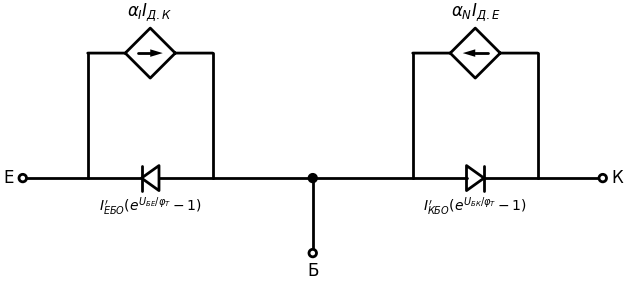

In [7]:
# Еквівалентна схема Еберса–Молла для n-p-n: два діоди + два керовані джерела струму
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        B = (5, 0)
        d.add(elm.Dot().at(B)); d.add(elm.Line().endpoints(B, (5, -1.5))); d.add(elm.Dot(open=True).at((5, -1.5)).label('Б', loc='bottom'))
        # ліва частина: емітер
        d.add(elm.Line().endpoints(B, (3, 0)))
        d.add(elm.Diode().endpoints((3, 0), (0.5, 0)).label('$I_{ЕБО}\'(e^{U_{БЕ}/\\varphi_T}-1)$', loc='bottom', fontsize=10))
        d.add(elm.Line().endpoints((3, 0), (3, 2.5))); d.add(elm.Line().endpoints((0.5, 0), (0.5, 2.5)))
        d.add(elm.SourceControlledI().endpoints((0.5, 2.5), (3, 2.5)).label('$\\alpha_I I_{Д.К}$'))
        d.add(elm.Line().endpoints((0.5, 0), (-0.8, 0))); d.add(elm.Dot(open=True).at((-0.8, 0)).label('Е', loc='left'))
        # права частина: колектор
        d.add(elm.Line().endpoints(B, (7, 0)))
        d.add(elm.Diode().endpoints((7, 0), (9.5, 0)).label('$I_{КБО}\'(e^{U_{БК}/\\varphi_T}-1)$', loc='bottom', fontsize=10))
        d.add(elm.Line().endpoints((7, 0), (7, 2.5))); d.add(elm.Line().endpoints((9.5, 0), (9.5, 2.5)))
        d.add(elm.SourceControlledI().endpoints((9.5, 2.5), (7, 2.5)).label('$\\alpha_N I_{Д.Е}$'))
        d.add(elm.Line().endpoints((9.5, 0), (10.8, 0))); d.add(elm.Dot(open=True).at((10.8, 0)).label('К', loc='right'))

На схемі: $I_{Д.Е}$ і $I_{Д.К}$ — струми «діодів» емітерного і колекторного переходів; ромбоподібні символи — **джерела струму, керовані струмом** (стрілка показує напрямок струму). Діоди обох переходів спрямовані від бази (p) до емітера й колектора (n).

### ⚙️ PySpice: режими роботи транзистора 2N3904 <a class="anchor" id="spice-modes"></a>

Напруги $U_{БЕ}$ і $U_{БК}$ задаються джерелами (емітер заземлено, $U_{КЕ} = U_{БЕ} - U_{БК}$), струми розраховує ngspice за моделлю Гуммеля–Пуна транзистора 2N3904. Перевірте: в активному режимі $I_к \approx \beta I_б$ і майже не залежить від $U_{БК}$; у насиченні $I_к/I_б$ різко падає; в інверсному режимі струм колектора змінює знак.

In [8]:
def bjt_mode(U_BE=0.68, U_BC=-3.0):
    c = Circuit('Mode explorer'); c.include(lib('bjt'))
    c.V('be', 'b', c.gnd, U_BE); c.V('ce', 'c', c.gnd, U_BE - U_BC)
    c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
    op = c.simulator().operating_point()
    Ib, Ic = -float(op.branches['vbe'][0]), -float(op.branches['vce'][0]); Ie = Ib + Ic
    eb, cb = U_BE > 0.45, U_BC > 0.45
    mode = {(True, False): 'АКТИВНИЙ', (True, True): 'НАСИЧЕННЯ', (False, False): 'ВІДСІЧКА', (False, True): 'ІНВЕРСНИЙ'}[(eb, cb)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    ax = axes[0]
    for (x0, y0, x1, y1), col in [((0.45, -6, 0.85, 0.45), '#dcfce7'), ((0.45, 0.45, 0.85, 0.85), '#fee2e2'),
                                   ((-1, -6, 0.45, 0.45), '#e0e7ff'), ((-1, 0.45, 0.45, 0.85), '#fef9c3')]:
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, fc=col, ec='none'))
    ax.text(0.6, -5.5, 'активний', fontsize=10); ax.text(0.6, 0.62, 'насичення', fontsize=10)
    ax.text(-0.95, -5.5, 'відсічка', fontsize=10); ax.text(-0.95, 0.62, 'інверсний', fontsize=10)
    ax.plot(U_BE, U_BC, 'ko', ms=10)
    ax.set_xlim(-1, 0.85); ax.set_ylim(-6, 0.85); ax.set_xlabel('$U_{БЕ}$, В'); ax.set_ylabel('$U_{БК}$, В')
    ax.set_title(f'Режим: {mode}'); ax.grid(False)
    ax = axes[1]
    vals = [Ie*1e3, Ib*1e3, Ic*1e3]
    ax.bar(['$I_е$ (витікає)', '$I_б$ (втікає)', '$I_к$ (втікає)'], vals, color=['#7c3aed', '#16a34a', '#2563eb'])
    ax.axhline(0, color='k', lw=0.8); ax.set_ylabel('мА'); ax.set_title('Струми виводів (додатні — за стрілками n-p-n)')
    for k, v in enumerate(vals): ax.text(k, v, f'{v:.3g}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
    plt.tight_layout(); plt.show()
    print(f'U_КЕ = {U_BE - U_BC:.2f} В;  I_к = {Ic*1e3:.4g} мА, I_б = {Ib*1e6:.4g} мкА, I_е = {Ie*1e3:.4g} мА')
    if abs(Ib) > 1e-12: print(f'I_к/I_б = {Ic/Ib:.1f};  I_к/I_е = {Ic/Ie:.4f}')

interact(bjt_mode,
         U_BE=widgets.FloatSlider(min=-1.0, max=0.8, step=0.01, value=0.68, description='$U_{БЕ}$, В', continuous_update=False),
         U_BC=widgets.FloatSlider(min=-6.0, max=0.8, step=0.01, value=-3.0, description='$U_{БК}$, В', continuous_update=False));

interactive(children=(FloatSlider(value=0.68, continuous_update=False, description='$U_{БЕ}$, В', max=0.8, min…

---
### ✅ Питання для самоперевірки: Принцип дії біполярного транзистора

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому база біполярного транзистора має бути тонкою?</summary>

> **Відповідь:** Щоб інжектовані емітером неосновні носії встигли продифундувати до колекторного переходу, не рекомбінувавши: коефіцієнт перенесення $\varkappa \approx 1 - W^2/2L^2$ близький до 1 лише при $W \ll L$. Якщо $W \gtrsim L$, переходи перестають взаємодіяти — маємо два окремі діоди.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому емітер легують сильніше за базу?</summary>

> **Відповідь:** Щоб ефективність емітера $\gamma$ була близька до 1: струм через емітерний перехід має переноситися переважно електронами, які інжектуються в базу (корисний струм), а не дірками, що інжектуються з бази в емітер (частина струму бази).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому колекторний струм в активному режимі майже не залежить від напруги на колекторі?</summary>

> **Відповідь:** Колекторний перехід лише збирає носії, що дійшли до нього, а їх кількість визначає інжекція емітера (тобто $U_{БЕ}$). Збільшення зворотної напруги на колекторі не змінює кількості носіїв, що надходять, — колектор поводиться як джерело струму (невеликий нахил дає ефект Ерлі).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Як розпізнати режим насичення n-p-n транзистора, маючи лише вольтметр?</summary>

> **Відповідь:** Виміряти $U_{БЕ}$ і $U_{КЕ}$: якщо $U_{БЕ} \approx 0{,}7$ В і $U_{КЕ} < U_{БЕ}$ (зазвичай 0,05–0,3 В), колекторний перехід зміщений прямо — насичення.

</details>

---

# Схеми ввімкнення біполярного транзистора <a class="anchor" id="bjt-configs"></a>

Транзистор має три виводи, а підсилювальний каскад — вхідне й вихідне кола (чотириполюсник). Тому один з виводів — **спільний** для входу й виходу. Звідси три схеми ввімкнення:

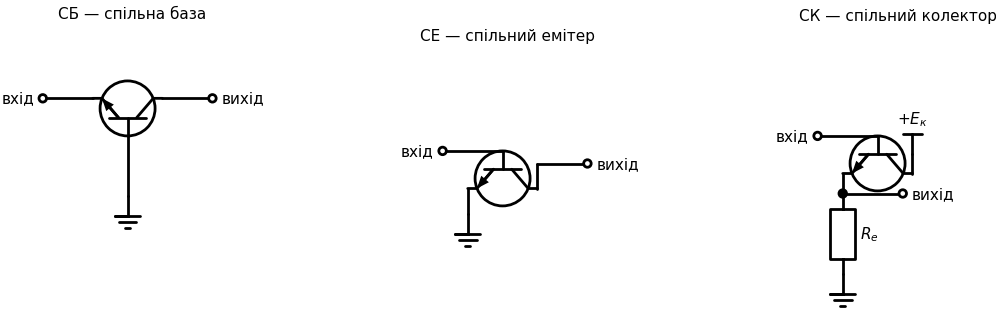

In [9]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        # --- СБ: емітер ліворуч (вхід), колектор праворуч (вихід), база — донизу на спільний провід
        t = d.add(elm.BjtNpn(circle=True).at((2, 0)).theta(90).flip())
        d.add(elm.Line().at(t.emitter).left(1.0)); d.add(elm.Dot(open=True).label('вхід', loc='left'))
        d.add(elm.Line().at(t.collector).right(1.0)); d.add(elm.Dot(open=True).label('вихід', loc='right'))
        d.add(elm.Line().at(t.base).down(1.2)); d.add(elm.Ground())
        d.add(elm.Label().at((t.center[0], t.center[1] + 1.8)).label('СБ — спільна база'))
        # --- СЕ: база — вхід, колектор — вихід, емітер — на спільний провід
        t2 = d.add(elm.BjtNpn(circle=True).at((9.5, -0.3)))
        d.add(elm.Line().at(t2.base).left(1.2)); d.add(elm.Dot(open=True).label('вхід', loc='left'))
        d.add(elm.Line().at(t2.collector).up(0.5)); d.add(elm.Line().right(1.0)); d.add(elm.Dot(open=True).label('вихід', loc='right'))
        d.add(elm.Line().at(t2.emitter).down(0.5)); d.add(elm.Ground())
        d.add(elm.Label().at((t2.center[0], 2.1)).label('СЕ — спільний емітер'))
        # --- СК: база — вхід, емітер — вихід, колектор — на джерело живлення (для змінного струму — спільний провід)
        t3 = d.add(elm.BjtNpn(circle=True).at((17, 0)))
        d.add(elm.Line().at(t3.base).left(1.2)); d.add(elm.Dot(open=True).label('вхід', loc='left'))
        d.add(elm.Line().at(t3.collector).up(0.4)); d.add(elm.Vdd().label('$+E_к$', fontsize=11))
        d.add(elm.Line().at(t3.emitter).down(0.4)); d.add(elm.Dot()); d.push()
        d.add(elm.Line().right(1.2)); d.add(elm.Dot(open=True).label('вихід', loc='right')); d.pop()
        d.add(elm.Resistor().down(1.6).label('$R_е$', loc='bottom')); d.add(elm.Ground())
        d.add(elm.Label().at((t3.center[0] + 0.3, 2.5)).label('СК — спільний колектор'))

| Параметр | СБ | СЕ | СК (емітерний повторювач) |
|---|---|---|---|
| Коефіцієнт підсилення струму $K_I$ | $\alpha \approx 1$ (трохи менше) | $\beta$ = 50–500 | $\beta + 1$ |
| Коефіцієнт підсилення напруги $K_U$ | великий | великий | $\approx 1$ (трохи менше) |
| Підсилення потужності | середнє | **найбільше** | середнє |
| Вхідний опір | малий (одиниці–десятки Ом) | середній (сотні Ом – кОм) | великий (десятки–сотні кОм) |
| Вихідний опір | дуже великий | середній–великий | малий (одиниці–десятки Ом) |
| Фаза вихідної напруги | не змінюється | **інвертується** (180°) | не змінюється |
| Частотні властивості | найкращі ($f_\alpha$) | обмежені ефектом Міллера ($f_\beta = f_\alpha/\beta$) | добрі |
| Застосування | широкосмугові, НВЧ-каскади, каскод | універсальні підсилювачі, ключі | буфери, узгодження опорів, вихідні каскади |

Схема **СЕ** — найпоширеніша: лише вона одночасно підсилює і струм, і напругу. **СК** не підсилює напругу, але має великий вхідний і малий вихідний опір — ідеальний буфер. **СБ** не підсилює струм, але має найкращі частотні властивості.

### ⚙️ PySpice: коефіцієнти передачі струму в схемах СБ, СЕ, СК <a class="anchor" id="spice-configs"></a>

Для кожної схеми змінюємо вхідний струм і вимірюємо вихідний (напруга на колекторі відносно бази/емітера — 5 В). Нахил характеристики — статичний коефіцієнт передачі струму.

In [10]:
def config_gain(config='СЕ: вхід — база, вихід — колектор'):
    c = Circuit('Configs'); c.include(lib('bjt'))
    if config.startswith('СБ'):
        c.I('in', 'e', c.gnd, 0)              # струм, що витікає з емітера (джерело тягне струм з емітера в землю)
        c.V('cb', 'c', c.gnd, 5); c.BJT(1, 'c', c.gnd, 'e', model='Q2N3904')       # база заземлена
        an = c.simulator().dc(Iin=slice(0, 10e-3, 0.1e-3))
        Iin = np.array(an.sweep); Iout = -np.array(an.branches['vcb'])
        xl, yl = '$I_е$, мА', '$I_к$, мА'; name = 'α'
    elif config.startswith('СЕ'):
        c.I('in', c.gnd, 'b', 0); c.V('ce', 'c', c.gnd, 5); c.BJT(1, 'c', 'b', c.gnd, model='Q2N3904')
        an = c.simulator().dc(Iin=slice(0, 60e-6, 0.5e-6))
        Iin = np.array(an.sweep); Iout = -np.array(an.branches['vce'])
        xl, yl = '$I_б$, мА', '$I_к$, мА'; name = 'β'
    else:
        c.I('in', c.gnd, 'b', 0); c.V('cc', 'c', c.gnd, 10); c.V('em', 'e', c.gnd, 5)
        c.BJT(1, 'c', 'b', 'e', model='Q2N3904')
        an = c.simulator().dc(Iin=slice(0, 60e-6, 0.5e-6))
        Iin = np.array(an.sweep); Iout = np.array(an.branches['vem'])
        xl, yl = '$I_б$, мА', '$I_е$, мА'; name = 'β + 1'
    k = len(Iin)//2
    slope = np.gradient(Iout, Iin)[k]; static = Iout[k]/Iin[k]
    fig, ax = plt.subplots(figsize=(7.5, 4.3))
    ax.plot(Iin*1e3, Iout*1e3, color='#2563eb')
    ax.plot(Iin[k]*1e3, Iout[k]*1e3, 'ro')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(config)
    plt.tight_layout(); plt.show()
    print(f'Статичний коефіцієнт {name}: {static:.4g};  диференціальний (нахил) у середній точці: {slope:.4g}')

interact(config_gain, config=widgets.RadioButtons(options=['СБ: вхід — емітер, вихід — колектор', 'СЕ: вхід — база, вихід — колектор',
                                                           'СК: вхід — база, вихід — емітер'], value='СЕ: вхід — база, вихід — колектор',
                                                  layout=widgets.Layout(width='max-content')));

interactive(children=(RadioButtons(description='config', index=1, layout=Layout(width='max-content'), options=…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

«Транзистор підсилює, бо сам виробляє енергію» — хибно. Транзистор лише **керує** енергією джерела живлення колекторного кола: малий вхідний сигнал (струм бази або напруга база–емітер) змінює великий струм колектора, що тече від джерела $E_к$ через навантаження. Потужність сигналу на навантаженні більша за вхідну, але вся «додаткова» енергія береться від $E_к$ — ККД каскаду завжди менше 100 %.

</div>

---
### ✅ Питання для самоперевірки: Схеми ввімкнення та модель Еберса–Молла

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому схема СЕ інвертує фазу вихідної напруги?</summary>

> **Відповідь:** Збільшення вхідної напруги $U_{БЕ}$ збільшує струм колектора, і на резисторі в колі колектора падає більша напруга; напруга на колекторі $U_{КЕ} = E_к - I_кR_к$ при цьому зменшується — вихід змінюється в протифазі до входу.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому емітерний повторювач не підсилює напругу?</summary>

> **Відповідь:** Напруга на емітері «повторює» базову з відставанням на $U_{БЕ} \approx 0{,}65$ В, яка майже стала (логарифмічно залежить від струму). Змінна напруга на виході дорівнює вхідній мінус мала зміна $U_{БЕ}$, тому $K_U$ трохи менше 1.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що описує умова взаємності $\alpha_NI_{ЕБО}' = \alpha_II_{КБО}'$ у моделі Еберса–Молла?</summary>

> **Відповідь:** Що транзистор — пасивна взаємна структура: струм, переданий з емітера в колектор при заданій напрузі на емітерному переході, дорівнює струму, переданому з колектора в емітер при такій самій напрузі на колекторному. Обидва дорівнюють параметру $I_S$ SPICE-моделі.

</details>

---
### 📝 Задачі для самостійного розв'язання: Біполярний транзистор


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Транзистор має $\alpha = 0{,}99$. Струм емітера 10 мА. Знайдіть $\beta$, струми колектора і бази.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\beta = \alpha/(1-\alpha) = 99$; $I_к = \alpha I_е = 9{,}9$ мА; $I_б = I_е - I_к = 0{,}1$ мА.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** У транзистора $\beta = 150$, $I_{КБО} = 10$ нА. Знайдіть $I_{КЕО}$ і струм колектора при $I_б = 20$ мкА.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_{КЕО} = (\beta+1)I_{КБО} = 1{,}51$ мкА; $I_к = \beta I_б + I_{КЕО} = 3 + 0{,}0015 \approx 3{,}0015$ мА.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Оцініть $\gamma$, $\varkappa$ і $\beta$ n-p-n транзистора: $N_Е = 10^{19}$, $N_Б = 10^{17}$ см⁻³, $W = 1$ мкм, $D_n = 18{,}6$ см²/с, $L_n = 30$ мкм, $D_p = 1{,}8$ см²/с, $L_p = 1$ мкм.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\gamma = 1/(1 + D_pN_БW/(D_nN_ЕL_p)) = 1/(1 + 1{,}8\cdot10^{17}/(18{,}6\cdot10^{19})) = 0{,}99903$; $\varkappa = 1 - W^2/2L_n^2 = 0{,}99944$; $\alpha = 0{,}99848$; $\beta \approx 656$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** n-p-n транзистор: $U_{БЕ} = 0{,}7$ В. У якому режимі він працює при $U_{КЕ}$ = 5 В; 0,7 В; 0,15 В? А при $U_{БЕ} = -1$ В і $U_{КЕ} = 5$ В?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{БК} = U_{БЕ} - U_{КЕ}$: −4,3 В → **активний**; 0 В → межа активного режиму і насичення; +0,55 В → **насичення**. При $U_{БЕ} = -1$ В обидва переходи зміщені зворотно ($U_{БК} = -6$ В) → **відсічка**.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 5.** Колекторний струм транзистора в активному режимі $I_к = I_Se^{U_{БЕ}/\varphi_T}$. На скільки треба змінити $U_{БЕ}$, щоб $I_к$ зріс з 1 до 2 мА?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\Delta U_{БЕ} = \varphi_T\ln2 = 17{,}9$ мВ.

</details>

---

## 📌 Підсумок лекції 5: Біполярний транзистор: будова, принцип дії, режими <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Поняття | Суть |
|---|---|
| Будова | Емітер ($n^+$) – тонка база (p) – колектор (n); $W_Б \ll L$ |
| Активний режим | ЕП прямо, КП зворотно: інжекція → дифузія через базу → екстракція |
| Коефіцієнти | $\alpha = \gamma\varkappa \approx 0{,}98$–$0{,}998$; $\beta = \alpha/(1-\alpha) \approx 50$–$500$ |
| Основні рівняння | $I_е = I_к + I_б$; $I_к = \beta I_б + I_{КЕО}$; $I_к = I_Se^{U_{БЕ}/\varphi_T}$ |
| Режими | активний (підсилення), насичення і відсічка (ключ), інверсний |
| Модель | Еберса–Молла: два діоди + два джерела струму, керовані струмом |
| Схеми ввімкнення | СЕ — $K_I$ і $K_U$ великі; СБ — $K_I \approx 1$, найкраща ВЧ; СК — $K_U \approx 1$, буфер |

**Головні висновки.** (1) Транзисторний ефект виникає лише при взаємодії переходів через тонку базу. (2) Великий $\beta$ вимагає сильно легованого емітера й тонкої, слабше легованої бази. (3) Колектор в активному режимі — джерело струму, кероване струмом бази (або експоненційно — напругою $U_{БЕ}$). (4) Режим визначають знаки напруг на двох переходах. Наступна лекція — статичні характеристики, параметри і межі застосування.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 4. Напівпровідникові діоди та їх застосування](Лекція_04_Напівпровідникові_діоди_та_їх_застосування.ipynb) &nbsp;|&nbsp; [Лекція 6. Статичні характеристики та параметри біполярного транзистора](Лекція_06_Статичні_характеристики_біполярного_транзистора.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*